# Ethereum Fraud Detection — Data Cleaning & Preprocessing

**Pipeline:** acquire → quality check → drop identifiers/artifacts (with address-duplication check) → clean invalid values & impute missing → small feature-engineering step → correlation-based redundancy filtering → log1p transforms for skewed counts → final validation → save one CSV.

In [13]:
# ============================================================================
# 1.IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [14]:
# ============================================================================
# 2. LOAD DATA
# ============================================================================
df = pd.read_csv("transaction_dataset.csv")
print(f"\nLoaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded: 9841 rows x 51 columns


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS


# Ethereum Transaction Dataset: Column Guide

## 📊 Basic Account Information

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **Index** | This is just a row number for the dataset, like 1, 2, 3... It doesn't have any special meaning on the blockchain. |
| **Address** | This is like the **account number** for a user on the blockchain. It's a long string of letters and numbers (starting with `0x`). Think of it like a bank account number, but for cryptocurrency and digital assets. |
| **FLAG** | This is a label used for analysis, likely marking accounts with something notable. For example, `0` might mean a "normal" account, while `1` could mean it's been flagged as something like a scam, an exchange, or a smart contract. |

---

## ⏱️ Transaction Timing

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **Avg min between sent tnx** | The **average time** (in minutes) between this account **sending** a transaction. A low number (like 2 minutes) means this account is sending money very frequently. |
| **Avg min between received tnx** | The **average time** (in minutes) between this account **receiving** a transaction. A low number means it's getting money often. |
| **Time Diff between first and last (Mins)** | The **total time span** (in minutes) between the account's very first transaction and its very last transaction. It's basically the "age" of this account's activity. |

---

## 🔢 Transaction Counts and Relationships

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **Sent tnx** | The **total number** of transactions this account has **sent** (including regular transfers and creating contracts). |
| **Received Tnx** | The **total number** of transactions this account has **received**. |
| **Number of Created Contracts** | The number of **smart contracts** this account has created and deployed to the blockchain. A smart contract is like a self-executing digital agreement. |
| **Unique Received From Addresses** | The number of **different** accounts that have sent money *to* this account. |
| **Unique Sent To Addresses** | The number of **different** accounts this account has sent money *to*. |

---

## 💰 Value Statistics (in Ether - ETH)

> **Note:** Ether (ETH) is the native cryptocurrency of the Ethereum network.

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **min value received** | The **smallest amount** of Ether (in ETH) this account has received in a single transaction. |
| **max value received** | The **largest amount** of Ether this account has received in a single transaction. |
| **avg val received** | The **average amount** of Ether this account has received per transaction. |
| **min val sent** | The **smallest amount** of Ether this account has sent in a single transaction. |
| **max val sent** | The **largest amount** of Ether this account has sent in a single transaction. |
| **avg val sent** | The **average amount** of Ether this account has sent per transaction. |
| **min value sent to contract** | The smallest amount of Ether sent *specifically to a smart contract*. |
| **max val sent to contract** | The largest amount of Ether sent *specifically to a smart contract*. |
| **avg value sent to contract** | The average amount of Ether sent *specifically to a smart contract*. |

---

## 📈 Overall Financial Summary (in Ether)

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **total transactions** | Total number of all transactions the account has been involved in (including creating contracts). |
| **total Ether sent** | The **total amount** of Ether this account has ever sent out. |
| **total ether received** | The **total amount** of Ether this account has ever received. |
| **total ether sent contracts** | The total amount of Ether sent *to smart contracts*. |
| **total ether balance** | The **current balance** of Ether in this account. (Calculated as: Received - Sent). |

---

## 🪙 Token Statistics (ERC20)

> **Note:** ERC20 tokens are other cryptocurrencies or digital assets built on the Ethereum network. Think of them like different "apps" or "companies" issuing their own shares on the Ethereum platform.

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **Total ERC20 tnxs** | The total number of transactions involving **ERC20 tokens**. |
| **ERC20 total Ether received** | The total amount of Ether this account received from transactions *involving* tokens. |
| **ERC20 total ether sent** | The total amount of Ether this account sent from transactions *involving* tokens. |
| **ERC20 total Ether sent contract** | The total amount of Ether sent to smart contracts *specifically from token transactions*. |
| **ERC20 uniq sent addr** | The number of **different addresses** this account has sent tokens to. |
| **ERC20 uniq rec addr** | The number of **different addresses** this account has received tokens from. |
| **ERC20 uniq sent addr.1** | *(Likely a duplicate or a specific sub-set of token addresses sent to).* |
| **ERC20 uniq rec contract addr** | The number of **different smart contract addresses** this account has received tokens from. |

---

## ⏱️ Timing and Value for Token Transactions

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **ERC20 avg time between sent tnx** | The average time between sending token transactions. |
| **ERC20 avg time between rec tnx** | The average time between receiving token transactions. |
| **ERC20 avg time between rec 2 tnx** | *(Likely another average time for a different type of token receipt, possibly related to contracts).* |
| **ERC20 avg time between contract tnx** | The average time between token transactions that interacted with smart contracts. |
| **ERC20 min val rec** | The smallest amount of tokens received in a single transaction. |
| **ERC20 max val rec** | The largest amount of tokens received in a single transaction. |
| **ERC20 avg val rec** | The average amount of tokens received per transaction. |
| **ERC20 min val sent** | The smallest amount of tokens sent in a single transaction. |
| **ERC20 max val sent** | The largest amount of tokens sent in a single transaction. |
| **ERC20 avg val sent** | The average amount of tokens sent per transaction. |
| **ERC20 min val sent contract** | The smallest amount of tokens sent *specifically to a smart contract*. |
| **ERC20 max val sent contract** | The largest amount of tokens sent *specifically to a smart contract*. |
| **ERC20 avg val sent contract** | The average amount of tokens sent *specifically to a smart contract*. |

---

## 🏷️ Most Common Tokens Used

| Column Name | Explanation (in Plain English) |
|:---|:---|
| **ERC20 uniq sent token name** | The name of the token this account has sent to the **highest number of different** addresses. (e.g., it sent "OmiseGO" to many places). |
| **ERC20 uniq rec token name** | The name of the token this account has received from the **highest number of different** addresses. |
| **ERC20 most sent token type** | The name of the token this account has sent the **largest total quantity** of. |
| **ERC20_most_rec_token_type** | The name of the token this account has received the **largest total quantity** of. |


DATA QUALITY AUDIT

SHAPE: (9841, 51)

DTYPES:
 Unnamed: 0                                                int64
Index                                                     int64
Address                                                  object
FLAG                                                      int64
Avg min between sent tnx                                float64
Avg min between received tnx                            float64
Time Diff between first and last (Mins)                 float64
Sent tnx                                                  int64
Received Tnx                                              int64
Number of Created Contracts                               int64
Unique Received From Addresses                            int64
Unique Sent To Addresses                                  int64
min value received                                      float64
max value received                                      float64
avg val received                                        

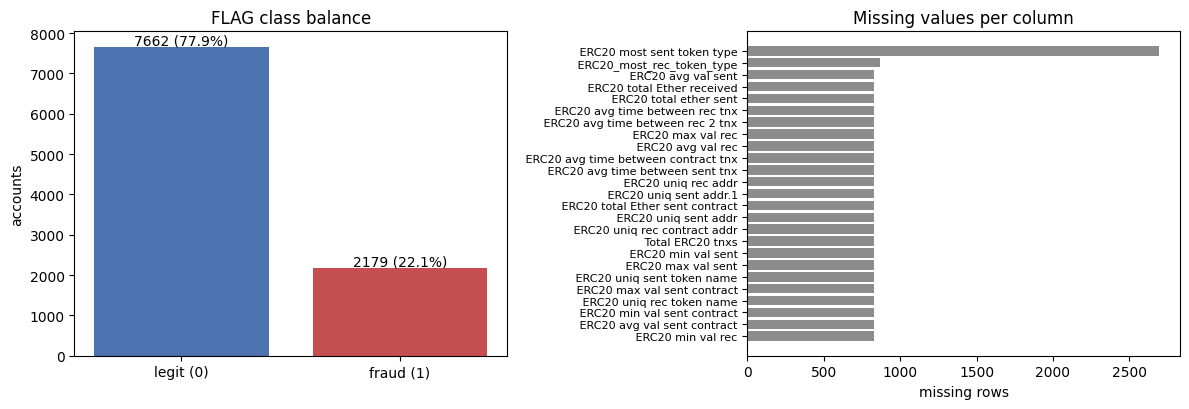

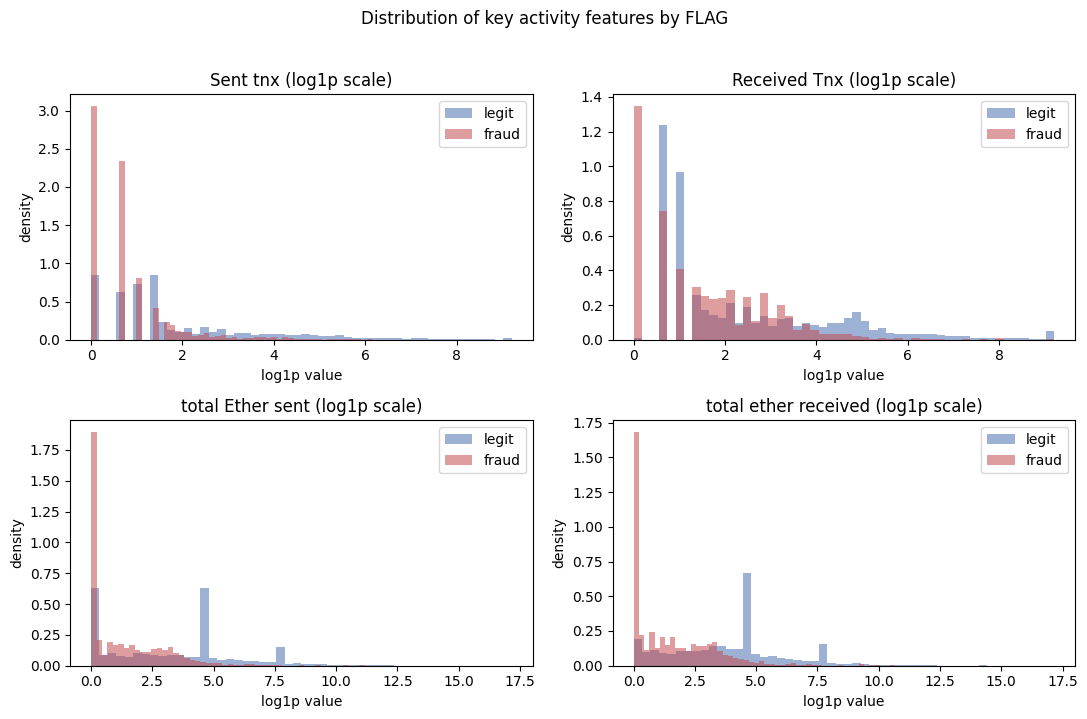

In [15]:
# ============================================================================
# 3. DATA QUALITY AUDIT 
# ============================================================================
print("=" * 80)
print("DATA QUALITY AUDIT")
print("=" * 80)

# 3a. Basic structure
print(f"\nSHAPE: {df.shape}")

# 3b. Dtypes
print("\nDTYPES:\n", df.dtypes.to_string())

# 3c. Missing values
print("\nMISSING VALUES (count / %):")
miss = pd.DataFrame({
    "col": df.columns,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2)
})
print(miss[miss.n_missing > 0].to_string(index=False))

# 3d. Duplicate rows
print(f"\nDUPLICATE ROWS (full): {df.duplicated().sum()}")

# 3e. Constant/near-constant columns 
nuniq = df.nunique()
const = nuniq[nuniq <= 2]
print("\nCONSTANT / NEAR-CONSTANT columns (<=2 unique values):")
print(const.to_string())

# 3f. Identifier columns
idlike = nuniq[nuniq == len(df)]
print("\nIDENTIFIER-LIKE columns (nunique == nrows):")
print(idlike.to_string())

# 3g. Class balance 
print("\nFLAG class balance:")
print(df["FLAG"].value_counts().to_string())
print(f"Fraud rate: {df['FLAG'].mean():.3%}")


# 3i. Visualizations 
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

# Class balance
ax = axes[0]
flag_counts = df["FLAG"].value_counts().sort_index()
bars = ax.bar(["legit (0)", "fraud (1)"], flag_counts.values, color=["#4C72B0", "#C44E52"])
for b, v in zip(bars, flag_counts.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 60, f"{v} ({v/len(df):.1%})", ha="center")
ax.set_title("FLAG class balance")
ax.set_ylabel("accounts")

# Missing values
ax = axes[1]
miss_sorted = df.isna().sum().sort_values(ascending=False)
miss_sorted = miss_sorted[miss_sorted > 0]
ax.barh(range(len(miss_sorted)), miss_sorted.values, color="#8C8C8C")
ax.set_yticks(range(len(miss_sorted)))
ax.set_yticklabels(miss_sorted.index, fontsize=8)
ax.invert_yaxis()
ax.set_title("Missing values per column")
ax.set_xlabel("missing rows")
fig.tight_layout()
plt.show()

# 3j. Feature distributions by FLAG
key_feats = ["Sent tnx", "Received Tnx", "total Ether sent", "total ether received"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, f in zip(axes.ravel(), key_feats):
    for flag, color, label in [(0, "#4C72B0", "legit"), (1, "#C44E52", "fraud")]:
        vals = np.log1p(df.loc[df["FLAG"] == flag, f].values)
        ax.hist(vals, bins=50, density=True, alpha=0.55, color=color, label=label)
    ax.set_title(f"{f} (log1p scale)")
    ax.set_xlabel("log1p value")
    ax.set_ylabel("density")
    ax.legend()
fig.suptitle("Distribution of key activity features by FLAG", y=1.02)
fig.tight_layout()
plt.show()

## What the plots showed

- **Class balance & missingness:** ~78% legit vs 22% fraud — imbalanced but workable (stratified splits later). The missing values were not random: they sit exactly on the ERC-20 columns and mark accounts with zero ERC-20 activity — which is why filling them with `0` was the right call.

- **Activity distributions by FLAG:** legit and fraud overlap heavily, but fraud concentrates at the **low-activity end** (many fraud accounts send/receive almost nothing), while legit accounts spread further toward high activity. No single feature separates the classes — a model needs the combination.

In [16]:
# ============================================================================
# 4. REMOVE IDENTIFIERS AND CONSTANTS 
# ============================================================================
print("\n" + "=" * 80)
print("REMOVING NON-INFORMATIVE COLUMNS")
print("=" * 80)

CONSTANT_COLS = [
    " ERC20 avg time between sent tnx",
    " ERC20 avg time between rec tnx",
    " ERC20 avg time between rec 2 tnx",
    " ERC20 avg time between contract tnx",
    " ERC20 min val sent contract",
    " ERC20 max val sent contract",
    " ERC20 avg val sent contract",
]
IDENTIFIER_COLS = ["Unnamed: 0", "Index", "Address"]

print(f"\nDropping {len(IDENTIFIER_COLS)} identifier columns: {IDENTIFIER_COLS}")
print(f"Dropping {len(CONSTANT_COLS)} constant columns (all 0.0)")

# Sanity check: Address duplication
feat_cols = [c for c in df.columns if c not in ("Unnamed: 0", "Index", "Address")]
shared = df["Address"].value_counts()
shared = shared[shared > 1]
print(f"\nAddresses appearing more than once: {len(shared)} (rows involved: {int(shared.sum())})")

n_identical = n_different = 0
for a in shared.index:
    rows = df.loc[df["Address"] == a, feat_cols]
    for i in range(1, len(rows)):
        same = (rows.iloc[0].fillna(0).values == rows.iloc[i].fillna(0).values).all()
        n_identical += int(same)
        n_different += int(not same)
print(f"  identical feature vectors (true duplicates): {n_identical}")
print(f"  different feature vectors (distinct profiles): {n_different}")

# Drop
removed_cols = IDENTIFIER_COLS + CONSTANT_COLS
df = df.drop(columns=removed_cols)
print(f"\nShape after removal: {df.shape}")


REMOVING NON-INFORMATIVE COLUMNS

Dropping 3 identifier columns: ['Unnamed: 0', 'Index', 'Address']
Dropping 7 constant columns (all 0.0)

Addresses appearing more than once: 25 (rows involved: 50)
  identical feature vectors (true duplicates): 18
  different feature vectors (distinct profiles): 7

Shape after removal: (9841, 41)


In [17]:
# ============================================================================
# 5. CLEAN COLUMN NAMES 
# ============================================================================
print("\n" + "=" * 80)
print("CLEANING COLUMN NAMES")
print("=" * 80)

RENAME = {
    "FLAG": "FLAG",
    "Avg min between sent tnx": "avg_min_between_sent_tnx",
    "Avg min between received tnx": "avg_min_between_received_tnx",
    "Time Diff between first and last (Mins)": "time_diff_first_last_mins",
    "Sent tnx": "sent_tnx",
    "Received Tnx": "received_tnx",
    "Number of Created Contracts": "created_contracts",
    "Unique Received From Addresses": "unique_received_from_addresses",
    "Unique Sent To Addresses": "unique_sent_to_addresses",
    "min value received": "min_value_received",
    "max value received ": "max_value_received",
    "avg val received": "avg_value_received",
    "min val sent": "min_value_sent",
    "max val sent": "max_value_sent",
    "avg val sent": "avg_value_sent",
    "min value sent to contract": "min_value_sent_to_contract",
    "max val sent to contract": "max_value_sent_to_contract",
    "avg value sent to contract": "avg_value_sent_to_contract",
    "total transactions (including tnx to create contract": "total_transactions",
    "total Ether sent": "total_ether_sent",
    "total ether received": "total_ether_received",
    "total ether sent contracts": "total_ether_sent_contracts",
    "total ether balance": "total_ether_balance",
    " Total ERC20 tnxs": "erc20_total_tnxs",
    " ERC20 total Ether received": "erc20_total_ether_received",
    " ERC20 total ether sent": "erc20_total_ether_sent",
    " ERC20 total Ether sent contract": "erc20_total_ether_sent_contract",
    " ERC20 uniq sent addr": "erc20_unique_sent_addresses",
    " ERC20 uniq rec addr": "erc20_unique_received_addresses",
    " ERC20 uniq sent addr.1": "erc20_unique_sent_contract_addresses",
    " ERC20 uniq rec contract addr": "erc20_unique_received_contract_addresses",
    " ERC20 min val rec": "erc20_min_value_received",
    " ERC20 max val rec": "erc20_max_value_received",
    " ERC20 avg val rec": "erc20_avg_value_received",
    " ERC20 min val sent": "erc20_min_value_sent",
    " ERC20 max val sent": "erc20_max_value_sent",
    " ERC20 avg val sent": "erc20_avg_value_sent",
    " ERC20 uniq sent token name": "erc20_unique_sent_token_names",
    " ERC20 uniq rec token name": "erc20_unique_received_token_names",
    " ERC20 most sent token type": "erc20_most_sent_token_type",
    " ERC20_most_rec_token_type": "erc20_most_received_token_type",
}
assert set(RENAME) == set(df.columns)
df = df.rename(columns=RENAME)
print("Column names cleaned.")


CLEANING COLUMN NAMES
Column names cleaned.


In [18]:
# ============================================================================
# 6. HANDLE INVALID VALUES & IMPUTE
# ============================================================================
print("\n" + "=" * 80)
print("HANDLING INVALID VALUES & IMPUTATION")
print("=" * 80)

TOKEN_TYPE_COLS = ["erc20_most_sent_token_type", "erc20_most_received_token_type"]
ERC20_ACTIVITY_COLS = [c for c in df.columns if c.startswith("erc20_") and c not in TOKEN_TYPE_COLS]

# 6a. Clean object columns
for c in df.select_dtypes(include="object").columns:
    df[c] = df[c].astype("string").str.strip()
    df[c] = df[c].replace("", pd.NA)

# 6b. "0" in token-type = no token type recorded -> missing
for c in TOKEN_TYPE_COLS:
    df[c] = df[c].replace("0", pd.NA)

# 6c. Infinity guard
n_inf = int(np.isinf(df.select_dtypes("number").to_numpy()).sum())
df = df.replace([np.inf, -np.inf], np.nan)

# 6d. Imputation 
n_before = int(df[ERC20_ACTIVITY_COLS].isna().sum().sum())
df[ERC20_ACTIVITY_COLS] = df[ERC20_ACTIVITY_COLS].fillna(0)

for c in TOKEN_TYPE_COLS:
    df[c] = df[c].fillna("Unknown")

print(f"Imputed {n_before} ERC-20 activity cells with 0 (semantic: no ERC-20 activity)")

# 6e. Verify
assert df.isna().sum().sum() == 0
assert np.isinf(df.select_dtypes("number").to_numpy()).sum() == 0
print("✓ No NaN, no inf remaining")


HANDLING INVALID VALUES & IMPUTATION
Imputed 13264 ERC-20 activity cells with 0 (semantic: no ERC-20 activity)
✓ No NaN, no inf remaining


In [19]:
# ============================================================================
# 7. FEATURE ENGINEERING 
# ============================================================================
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)

engineered_cols = {}
engineered_cols["sent_received_ratio"] = df["sent_tnx"] / (df["received_tnx"] + 1)
engineered_cols["counterparty_diversity"] = (
    (df["unique_received_from_addresses"] + df["unique_sent_to_addresses"])
    / (df["received_tnx"] + df["sent_tnx"] + 1)
)
engineered_cols["avg_ether_sent_per_tnx"] = df["total_ether_sent"] / (df["sent_tnx"] + 1)
engineered_cols["avg_ether_received_per_tnx"] = df["total_ether_received"] / (df["received_tnx"] + 1)

# ERC-20 shares: verified denominator is sum of both flows 
engineered_cols["erc20_sent_share"] = df["erc20_total_ether_sent"] / (
    df["erc20_total_ether_sent"] + df["total_ether_sent"] + 1
)
engineered_cols["erc20_received_share"] = df["erc20_total_ether_received"] / (
    df["erc20_total_ether_received"] + df["total_ether_received"] + 1
)

df = pd.concat([df, pd.DataFrame(engineered_cols, index=df.index)], axis=1)

# Verify
assert df[list(engineered_cols)].isna().sum().sum() == 0
assert np.isinf(df[list(engineered_cols)].to_numpy()).sum() == 0
assert df[["counterparty_diversity", "erc20_sent_share", "erc20_received_share"]].max().max() < 1.0

print(f"Created {len(engineered_cols)} engineered features")
print("  - sent_received_ratio")
print("  - counterparty_diversity")
print("  - avg_ether_sent_per_tnx")
print("  - avg_ether_received_per_tnx")
print("  - erc20_sent_share (verified [0,1))")
print("  - erc20_received_share (verified [0,1))")


FEATURE ENGINEERING
Created 6 engineered features
  - sent_received_ratio
  - counterparty_diversity
  - avg_ether_sent_per_tnx
  - avg_ether_received_per_tnx
  - erc20_sent_share (verified [0,1))
  - erc20_received_share (verified [0,1))



REDUNDANCY REDUCTION


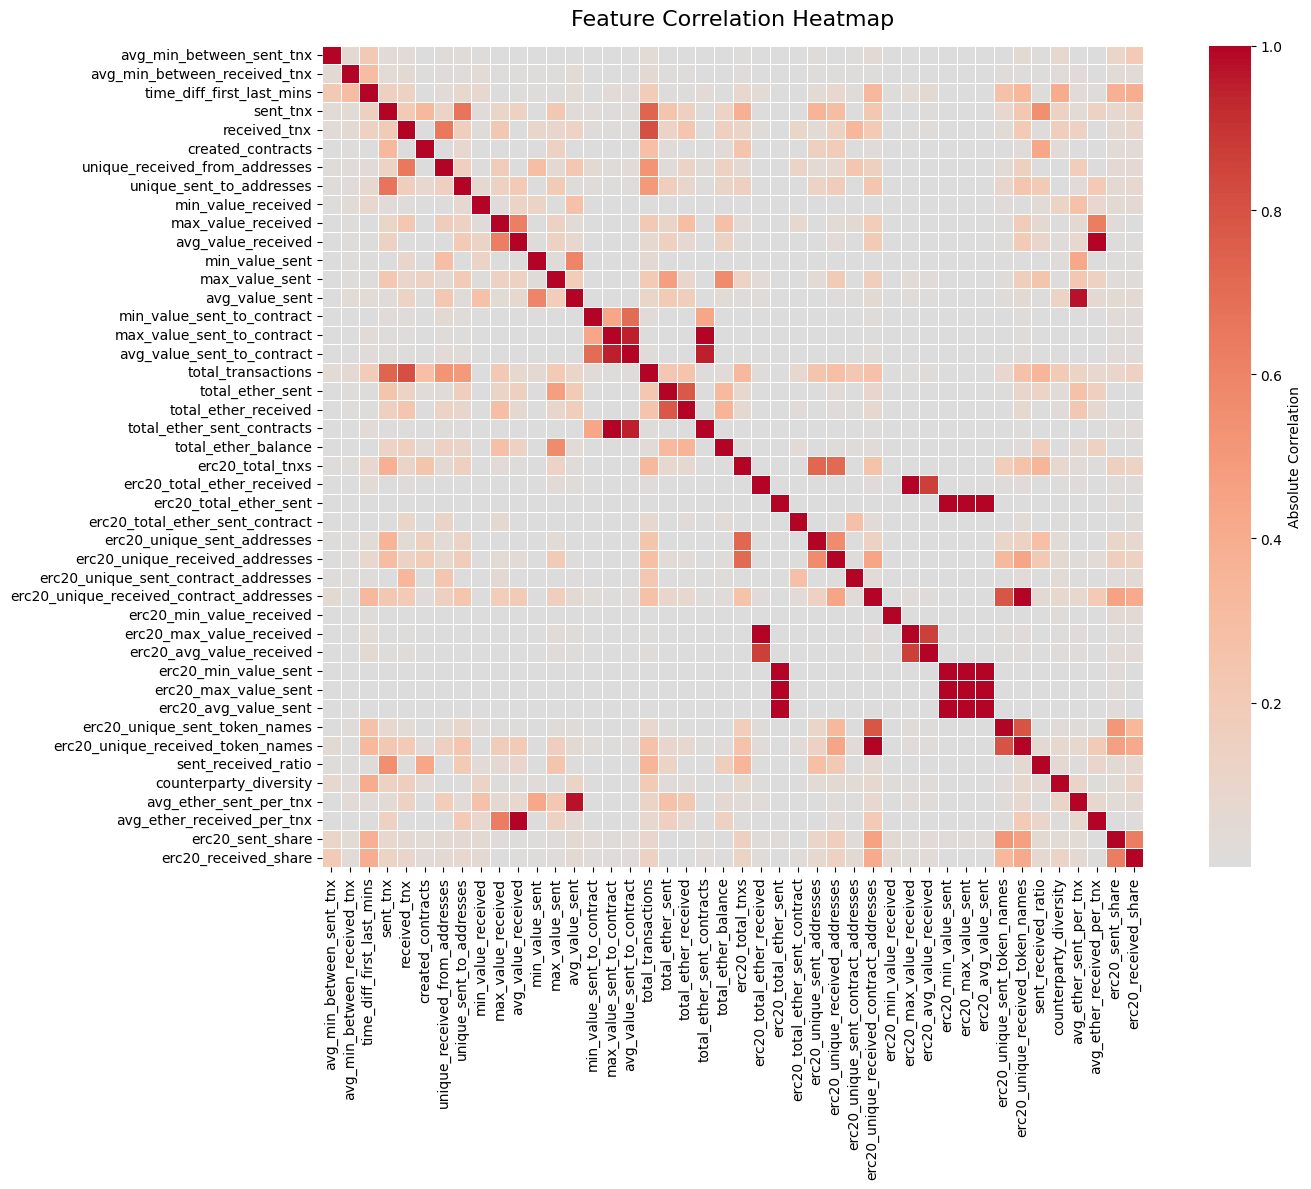

In [ ]:
# Correlation Heatmap

NUM_COLS = [c for c in df.columns if c != "FLAG" and df[c].dtype.kind in "fi"]

corr = df[NUM_COLS].corr().abs()
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Absolute Correlation"}
)

plt.title("Feature Correlation Heatmap", fontsize=16, pad=15)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



In [ ]:
# ============================================================================
# 8. REDUNDANCY REDUCTION 
# ============================================================================

print("\n" + "=" * 80)
print("REDUNDANCY REDUCTION")
print("=" * 80)

# 8a. Correlation filtering 
pairs = []

for i, a in enumerate(NUM_COLS):
    for b in NUM_COLS[i + 1:]:
        r = corr.loc[a, b]
        if r > 0.90:
            pairs.append((r, a, b))
pairs.sort(reverse=True)

print(f"Pairs with |corr| > 0.90: {len(pairs)}")

# 8b. Mutual Information 
# Fill temporary for MI computation
df_temp = df[NUM_COLS + ["FLAG"]].copy()
df_temp[NUM_COLS] = df_temp[NUM_COLS].fillna(0)
mi = pd.Series(
    mutual_info_classif(df_temp[NUM_COLS], df_temp["FLAG"], random_state=42),
    index=NUM_COLS
)

# 8c. Drop rule
ENGINEERED_DUPES = {
    "avg_ether_sent_per_tnx": "avg_value_sent",
    "avg_ether_received_per_tnx": "avg_value_received"
}

def pick_drop(a, b):
    if a in ENGINEERED_DUPES and ENGINEERED_DUPES[a] == b:
        return a
    if b in ENGINEERED_DUPES and ENGINEERED_DUPES[b] == a:
        return b
    if a == "total_transactions" and b in ("sent_tnx", "received_tnx"):
        return a
    if b == "total_transactions" and a in ("sent_tnx", "received_tnx"):
        return b
    return a if mi[a] <= mi[b] else b

drop_corr, reasons = set(), []
for r, a, b in pairs:
    if a in drop_corr or b in drop_corr:
        continue
    d = pick_drop(a, b)
    drop_corr.add(d)
    keep = b if d == a else a
    reasons.append(f"  drop {d:32s} (MI={mi[d]:.4f}) keep {keep:32s} (MI={mi[keep]:.4f})  r={r:.3f}")

print(f"\nRedundancy drop ({len(drop_corr)} features):")
for line in reasons:
    print(line)

df = df.drop(columns=sorted(drop_corr))
NUM_COLS = [c for c in NUM_COLS if c not in drop_corr]

print(f"\nShape after correlation filtering: {df.shape}")

# 8d. MI scores for reference 
mi = pd.Series(
    mutual_info_classif(df[NUM_COLS], df["FLAG"], random_state=42),
    index=NUM_COLS
)
print("\nMutual Information with FLAG (reference only):")
print(mi.sort_values(ascending=False).round(4).to_string())

print("\n✓ MI-based removal: SKIPPED by design (feature selection belongs in modeling)")

Pairs with |corr| > 0.90: 13

Redundancy drop (9 features):
  drop max_value_sent_to_contract       (MI=0.0000) keep total_ether_sent_contracts       (MI=0.0000)  r=1.000
  drop erc20_total_ether_received       (MI=0.0753) keep erc20_max_value_received         (MI=0.0828)  r=1.000
  drop erc20_avg_value_sent             (MI=0.0061) keep erc20_max_value_sent             (MI=0.0127)  r=1.000
  drop erc20_min_value_sent             (MI=0.0040) keep erc20_max_value_sent             (MI=0.0127)  r=1.000
  drop erc20_max_value_sent             (MI=0.0127) keep erc20_total_ether_sent           (MI=0.0178)  r=1.000
  drop erc20_unique_received_token_names (MI=0.0654) keep erc20_unique_received_contract_addresses (MI=0.0714)  r=1.000
  drop avg_ether_received_per_tnx       (MI=0.1709) keep avg_value_received               (MI=0.1758)  r=0.999
  drop avg_ether_sent_per_tnx           (MI=0.0719) keep avg_value_sent                   (MI=0.0781)  r=0.974
  drop total_ether_sent_contracts       (MI

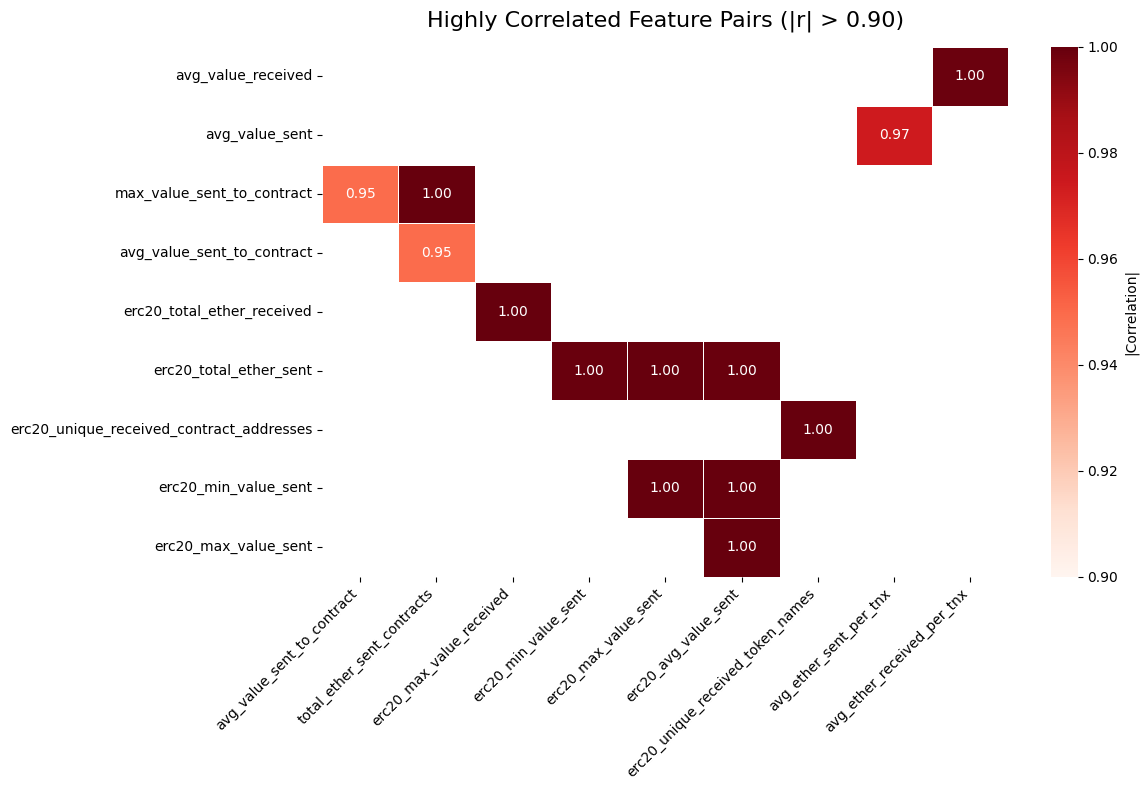

In [30]:
high_corr = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

high_corr = high_corr.where(high_corr > 0.90).dropna(
    axis=0, how="all"
).dropna(
    axis=1, how="all"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    high_corr,
    cmap="Reds",
    vmin=0.90,
    vmax=1.0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "|Correlation|"}
)

plt.title(
    "Highly Correlated Feature Pairs (|r| > 0.90)",
    fontsize=16,
    pad=15
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [22]:

# ============================================================================
# 9. LOG TRANSFORM 
# ============================================================================
print("\n" + "=" * 80)
print("LOG TRANSFORM FOR SKEWED FEATURES")
print("=" * 80)

NUM_COLS = [c for c in df.columns if c != "FLAG" and df[c].dtype.kind in "fi"]
skew_before = df[NUM_COLS].skew()
SKEW_THRESHOLD = 5.0
to_log = [c for c in NUM_COLS if skew_before[c] > SKEW_THRESHOLD and df[c].min() >= 0]

print(f"Features with skew > {SKEW_THRESHOLD}: {len(to_log)}")
for c in to_log:
    df[c] = np.log1p(df[c])

print("✓ Log transform applied. Raw = expm1(csv_value) to recover original units.")


LOG TRANSFORM FOR SKEWED FEATURES
Features with skew > 5.0: 30
✓ Log transform applied. Raw = expm1(csv_value) to recover original units.


/tmp/ipykernel_554486/3655284701.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


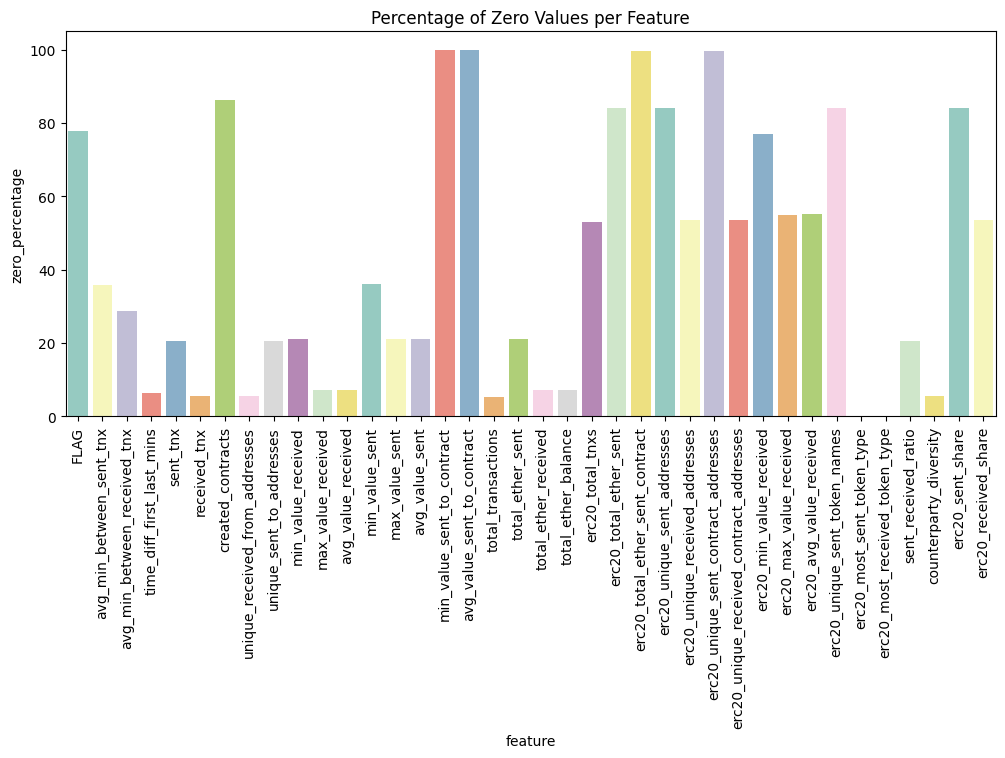

In [23]:
# Zero-value analysis 

def show_zero_values(): 
    global zero_values
    zero_values = {}

    for cols in df.columns:
        zero_values[cols] = (df[cols] == 0).sum() / len(df) * 100

    zero_df = pd.DataFrame(
        list(zero_values.items()),
        columns=['feature', 'zero_percentage']
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        data=zero_df,
        x='feature',
        y='zero_percentage',
        palette='Set3',
    )
    plt.tick_params(axis='x', rotation=90, labelsize=10)
    plt.title('Percentage of Zero Values per Feature')
    plt.show()

show_zero_values()

In [24]:
# ============================================================================
# 10. DUPLICATE HANDLING AND DROP HIGH ZERO COLUMNS
# ============================================================================
print("\n" + "=" * 80)
print("DUPLICATE HANDLING")
print("=" * 80)

n_dups = int(df.duplicated().sum())
if n_dups:
    dup_rows = df[df.duplicated(keep=False)]
    n_profiles = int(dup_rows.drop_duplicates().shape[0])
    print(f"Exact duplicates: {n_dups} rows across {n_profiles} distinct profiles")
    print("  (identical in all features; keeping one representative per profile)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"✓ Dropped {n_dups} exact duplicates")

# Drop specific columns with >99% zeros
columns_to_drop = [
    'avg_value_sent_to_contract',
    'min_value_sent_to_contract',
    'erc20_unique_sent_contract_addresses',
    'erc20_total_ether_sent_contract'
]

print(f"Dropping {len(columns_to_drop)} columns with >99% zeros:")
for col in columns_to_drop:
    zero_pct = (df[col] == 0).sum() / len(df) * 100
    print(f"  {col}: {zero_pct:.1f}% zeros")

df = df.drop(columns=columns_to_drop)


DUPLICATE HANDLING
Exact duplicates: 546 rows across 28 distinct profiles
  (identical in all features; keeping one representative per profile)
✓ Dropped 546 exact duplicates
Dropping 4 columns with >99% zeros:
  avg_value_sent_to_contract: 100.0% zeros
  min_value_sent_to_contract: 100.0% zeros
  erc20_unique_sent_contract_addresses: 99.7% zeros
  erc20_total_ether_sent_contract: 99.7% zeros



EXPLORATORY PCA & UMAP
Explained variance: PC1=36.0%, PC2=20.0%


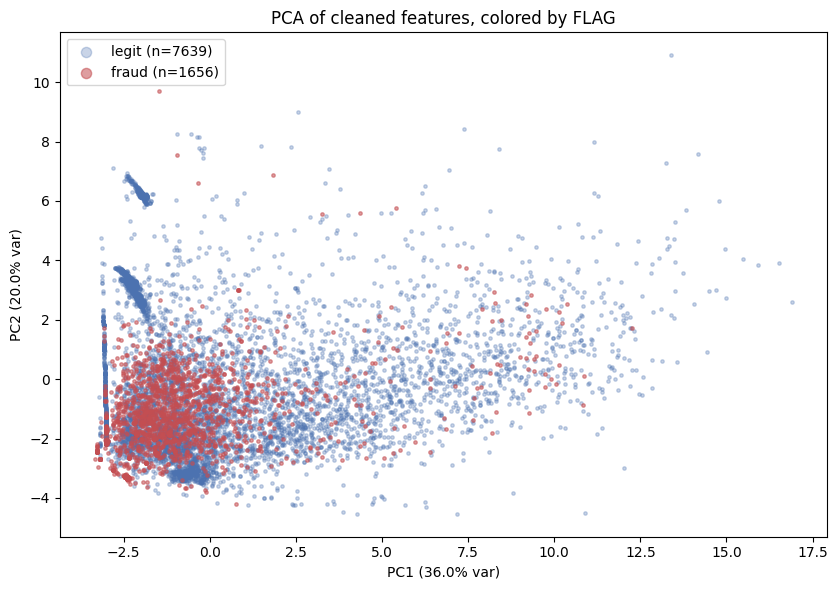

In [25]:
# ============================================================================
# 11. EXPLORATORY PCA 
# ============================================================================
print("\n" + "=" * 80)
print("EXPLORATORY PCA & UMAP")
print("=" * 80)

NUM_COLS = [c for c in df.columns if c != "FLAG" and df[c].dtype.kind in "fi"]
X = StandardScaler().fit_transform(df[NUM_COLS])
pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")

fig, ax = plt.subplots(figsize=(8.5, 6))
for flag, color, label, alpha in [(0, "#4C72B0", "legit", 0.30), (1, "#C44E52", "fraud", 0.55)]:
    m = df["FLAG"].values == flag
    ax.scatter(Z[m, 0], Z[m, 1], s=6, c=color, alpha=alpha, label=f"{label} (n={m.sum()})")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA of cleaned features, colored by FLAG")
ax.legend(markerscale=3)
fig.tight_layout()
plt.show()

I0000 00:00:1786290187.209876  554486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786290187.271889  554486 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786290188.986687  554486 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/mehraveh/ai-projects/ai-env/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/mehraveh/ai-projects/ai-env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by set

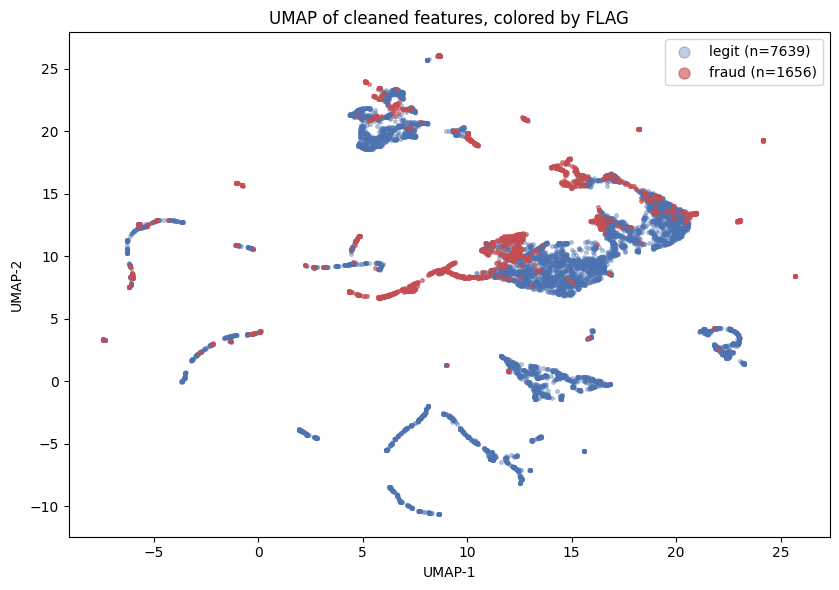

In [26]:
# UMAP if available
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    U = reducer.fit_transform(X)
    
    fig, ax = plt.subplots(figsize=(8.5, 6))
    for flag, color, label, alpha in [(0, "#4C72B0", "legit", 0.35), (1, "#C44E52", "fraud", 0.60)]:
        m = df["FLAG"].values == flag
        ax.scatter(U[m, 0], U[m, 1], s=7, c=color, alpha=alpha, label=f"{label} (n={m.sum()})")
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_title("UMAP of cleaned features, colored by FLAG")
    ax.legend(markerscale=3)
    fig.tight_layout()
    plt.show()
except ImportError:
    print("UMAP not installed - skipping")

## What the plots showed

- **PCA (2 dims, ≈50% of variance):** fraud and legit still mix, but fraud visibly clusters in a few regions, including one dense blob of the all-zero accounts. Real structure exists — but it's not a clean split.

- **UMAP (local structure):** the picture is sharper — fraud forms several **compact, well-separated clusters**. Takeaway: fraud is not one "type" but a handful of distinct behavioral patterns — a single rule won't catch everything, and this structure is a good reason to explore clustering or embeddings during modeling.

In [27]:
# ============================================================================
# 12. FINAL VALIDATION 
# ============================================================================
print("\n" + "=" * 80)
print("FINAL VALIDATION")
print("=" * 80)

# Helper function for safe checking
def safe_check(check_name, condition):
    try:
        result = bool(condition)
    except Exception as e:
        print(f"  ⚠ Check '{check_name}' raised error: {e}")
        result = False
    return result

# Run checks
checks = {}

# Core data quality checks
checks["No duplicate rows"] = safe_check("No duplicate rows", not df.duplicated().any())
checks["No missing values"] = safe_check("No missing values", df.isna().sum().sum() == 0)

# Numeric checks
num_cols = df.select_dtypes("number").columns
if len(num_cols) > 0:
    checks["No infinite values"] = safe_check("No infinite values", np.isinf(df[num_cols].to_numpy()).sum() == 0)
else:
    checks["No infinite values"] = True

checks["No constant features"] = safe_check("No constant features", (df.nunique() <= 1).sum() == 0)

# Column checks
checks["No identifier columns"] = safe_check("No identifier columns", 
    not any(c in df.columns for c in ["Unnamed: 0", "Index", "Address"]))

checks["FLAG preserved"] = safe_check("FLAG preserved", 
    "FLAG" in df.columns and set(df["FLAG"].unique()) <= {0, 1})

checks["Column names clean"] = safe_check("Column names clean", 
    df.columns.is_unique and df.columns.str.contains(r"^\w+$").all())

# Engineered features
engineered_features = ["sent_received_ratio", "counterparty_diversity", "erc20_sent_share", "erc20_received_share"]
existing_eng = [f for f in engineered_features if f in df.columns]
if existing_eng:
    checks["Engineered features valid"] = safe_check("Engineered features valid", 
        df[existing_eng].isna().sum().sum() == 0)
else:
    checks["Engineered features valid"] = True

checks["Reasonable feature count"] = safe_check("Reasonable feature count", 
    25 <= df.shape[1] <= 55)

# Print results
all_passed = True
for name, ok in checks.items():
    status = "✓ PASS" if ok else "✗ FAIL"
    print(f"{status}  {name}")
    if not ok:
        all_passed = False

# Assert only critical checks
critical = ["No duplicate rows", "No missing values", "FLAG preserved"]
for check in critical:
    if check in checks:
        assert checks[check], f"Critical check failed: {check}"

print("\n" + "=" * 80)
if all_passed:
    print("✓ ALL CHECKS PASSED")
else:
    print("⚠ Some checks failed - see above for details")
print("=" * 80)


FINAL VALIDATION
✓ PASS  No duplicate rows
✓ PASS  No missing values
✓ PASS  No infinite values
✓ PASS  No constant features
✓ PASS  No identifier columns
✓ PASS  FLAG preserved
✓ PASS  Column names clean
✓ PASS  Engineered features valid
✓ PASS  Reasonable feature count

✓ ALL CHECKS PASSED


In [28]:
# ============================================================================
# 13. FINAL SUMMARY
# ============================================================================
print("\n" + "=" * 80)
print("FINAL SUMMARY")
print("=" * 80)
print(f"Original shape:                 (9,841, 51)")
print(f"Final shape:                    {df.shape}")
print(f"Missing values remaining:        {int(df.isna().sum().sum())}")
print(f"Duplicate rows remaining:        {int(df.duplicated().sum())}")
print(f"Constant features remaining:     {int((df.nunique() <= 1).sum())}")
print(f"FLAG balance:                    {df['FLAG'].value_counts().to_dict()} (fraud rate {df['FLAG'].mean():.1%})")

# ============================================================================
# 14. SAVE 
# ============================================================================
df.to_csv("cleaned_transactions_dataset.csv", index=False)
print("\n✓ Saved: cleaned_transactions_dataset.csv")



FINAL SUMMARY
Original shape:                 (9,841, 51)
Final shape:                    (9295, 34)
Missing values remaining:        0
Duplicate rows remaining:        0
Constant features remaining:     0
FLAG balance:                    {0: 7639, 1: 1656} (fraud rate 17.8%)

✓ Saved: cleaned_transactions_dataset.csv


In [29]:
print(df.head(3).to_string())

   FLAG  avg_min_between_sent_tnx  avg_min_between_received_tnx  time_diff_first_last_mins  sent_tnx  received_tnx  created_contracts  unique_received_from_addresses  unique_sent_to_addresses  min_value_received  max_value_received  avg_value_received  min_value_sent  max_value_sent  avg_value_sent  total_transactions  total_ether_sent  total_ether_received  total_ether_balance  erc20_total_tnxs  erc20_total_ether_sent  erc20_unique_sent_addresses  erc20_unique_received_addresses  erc20_unique_received_contract_addresses  erc20_min_value_received  erc20_max_value_received  erc20_avg_value_received  erc20_unique_sent_token_names erc20_most_sent_token_type erc20_most_received_token_type  sent_received_ratio  counterparty_diversity  erc20_sent_share  erc20_received_share
0     0                  6.739644                      6.998245                  704785.63  6.582025      4.499810                0.0                        3.713572                  4.779123            0.000000          

##
## 🧹 Engineered Features

These are calculated features derived from the raw columns above, often used for machine learning and fraud detection.

| Column Name | Formula | What It Reveals |
|:---|:---|:---|
| **sent_received_ratio** | `sent_tnx / received_tnx` | **Behavior pattern**: Ratio > 1 = mostly sending (merchant/exchange/scammer). Ratio < 1 = mostly receiving (investor/collector). |
| **counterparty_diversity** | `(unique_sent_to + unique_received_from) / total_transactions` | **Network engagement**: High = interacts with many different entities (exchange/active trader). Low = limited interactions (personal wallet). |
| **erc20_sent_share** | `erc20_total_tnxs / total_transactions` | **Token usage**: High value = primarily deals with tokens. Low value = primarily deals with plain Ether. |
| **erc20_received_share** | *(Similar to above)* | **Token receipt**: Shows whether the account is primarily a token sender or receiver. |

---

## 📌 Why These Features Matter

| Feature | Use Case |
|:---|:---|
| **Log-transformed values** | Handle wide ranges (from 0.001 to millions) and make data more suitable for machine learning. |
| **sent_received_ratio** | Identify money laundering (high send ratio + low diversity), scam wallets, exchange activity. |
| **counterparty_diversity** | Detect suspicious patterns - low diversity often indicates interaction with a small, potentially malicious set of addresses. |
| **erc20_sent_share** | Distinguish between Ether-only users vs. active token traders. |
